# Histogramas

Um histograma é uma representação gráfica da distribuição de frequências de uma variável. Ele é um gráfico de barras onde cada barra representa uma classe ou intervalo de classe e a área de cada barra é proporcional à frequência da classe. 

O histograma é uma ferramenta útil para visualizar a forma da distribuição de uma variável. Ele permite identificar a presença de assimetria e a presença de outliers.

# Manipulaçao e tratamento de dados prévios

In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [42]:
ARQUIVO_DADOS = 'churn_clientes.csv'

df_churn = pd.read_csv(ARQUIVO_DADOS)
df_churn.head()

df_churn.describe(exclude='number')



,id_cliente,genero,idoso,tem_parceiro,tem_dependentes,servico_telefone,multiplas_linhas,servico_internet,servico_seguranca,servico_backup,servico_protecao_equipamento,servico_suporte_tecnico,streaming_tv,streaming_filmes,contrato,fatura_digital,forma_pagamento,churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,2,2,3,2,2,2,2,2,2,3,2,4,2
top,7590-VHVEG,Masculino,Não,Não,Não,Sim,Não,Fibra optica,Não,Não,Não,Não,Não,Não,Mensal,Sim,Boleto,Não
freq,1,3555,5901,3641,4933,6361,4072,3096,5024,4614,4621,4999,4336,4311,3875,4171,2365,5174


In [43]:
df_churn['churn'].value_counts()



churn
Não    5174
Sim    1869
Name: count, dtype: int64

In [44]:
df_churn['churn'].value_counts(normalize=True)*100



churn
Não    73.463013
Sim    26.536987
Name: proportion, dtype: float64

In [45]:
df_churn = df_churn.drop(columns='id_cliente', axis=1)



In [46]:
colunas_numericas = df_churn.select_dtypes(include='number').columns
print(colunas_numericas)

Index(['meses_na_empresa', 'valor_mensal', 'total_gasto'], dtype='object')


In [47]:
colunas_categoricas = df_churn.select_dtypes(exclude='number').columns
print(colunas_categoricas)

Index(['genero', 'idoso', 'tem_parceiro', 'tem_dependentes',
       'servico_telefone', 'multiplas_linhas', 'servico_internet',
       'servico_seguranca', 'servico_backup', 'servico_protecao_equipamento',
       'servico_suporte_tecnico', 'streaming_tv', 'streaming_filmes',
       'contrato', 'fatura_digital', 'forma_pagamento', 'churn'],
      dtype='object')


In [48]:
colunas_categoricas = colunas_categoricas.drop('churn')
colunas_categoricas

Index(['genero', 'idoso', 'tem_parceiro', 'tem_dependentes',
       'servico_telefone', 'multiplas_linhas', 'servico_internet',
       'servico_seguranca', 'servico_backup', 'servico_protecao_equipamento',
       'servico_suporte_tecnico', 'streaming_tv', 'streaming_filmes',
       'contrato', 'fatura_digital', 'forma_pagamento'],
      dtype='object')

# Iniciando histograma

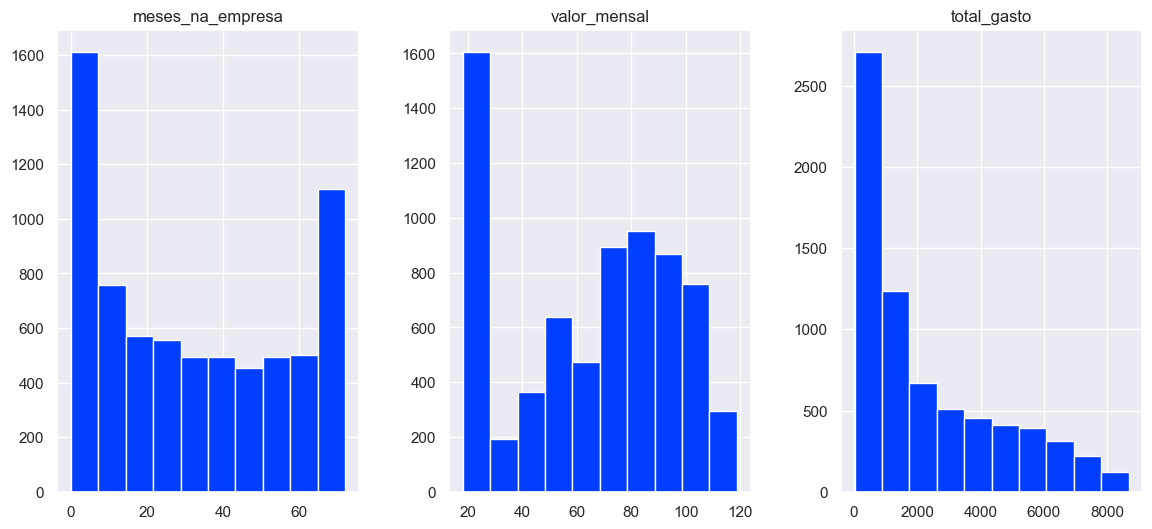

In [49]:
df_churn[colunas_numericas].hist(figsize=(14, 6),layout=(1,3));

In [50]:
#compreendendo melhor o histograma
#bins=número de registro para cada coluna

df_churn['meses_na_empresa'].value_counts(bins=10).sort_index()


(-0.073, 7.2]    1612
(7.2, 14.4]       759
(14.4, 21.6]      570
(21.6, 28.8]      556
(28.8, 36.0]      545
(36.0, 43.2]      444
(43.2, 50.4]      452
(50.4, 57.6]      495
(57.6, 64.8]      501
(64.8, 72.0]     1109
Name: count, dtype: int64

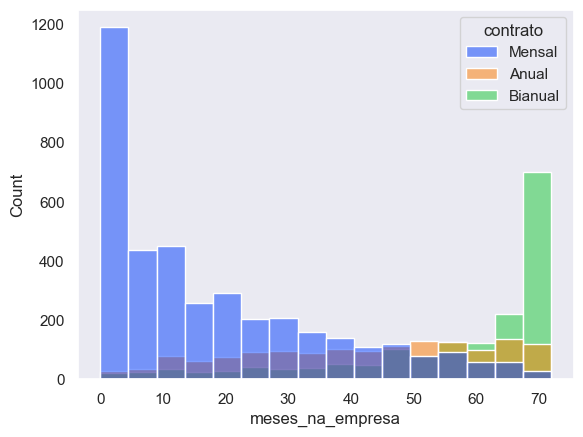

In [51]:
sns.set_theme(style='dark', palette='bright', context='notebook')

sns.histplot(x='meses_na_empresa', data=df_churn, hue='contrato');
# o que ganhamos com isso?

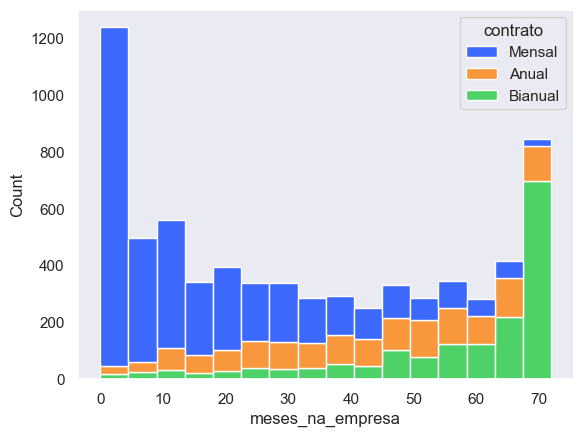

In [52]:
# ao invés de termos uma coluna na frente da outra, podemos ver uma sob a outras.
sns.histplot(x='meses_na_empresa', data=df_churn, hue='contrato', multiple='stack');

In [53]:
colunas_numericas

Index(['meses_na_empresa', 'valor_mensal', 'total_gasto'], dtype='object')

In [54]:
#Vamos visualizar a frequência das demais variáveis numéricas em relação a variável contrato

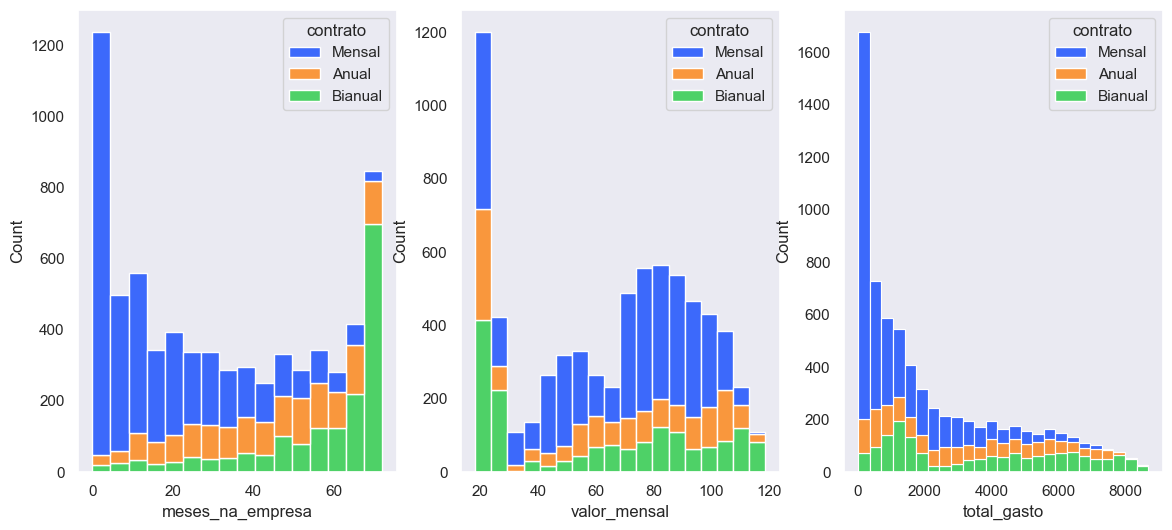

In [55]:
# vamos fazer isso com as demais variáveis numéricas
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(14, 6))

for i, coluna in enumerate(colunas_numericas):
    sns.histplot(x=coluna, data=df_churn, hue='contrato', multiple='stack', ax=axs[i])

plt.show()
#sns.histplot(x='meses_na_empresa', data=df_churn, hue='contrato', multiple='stack');

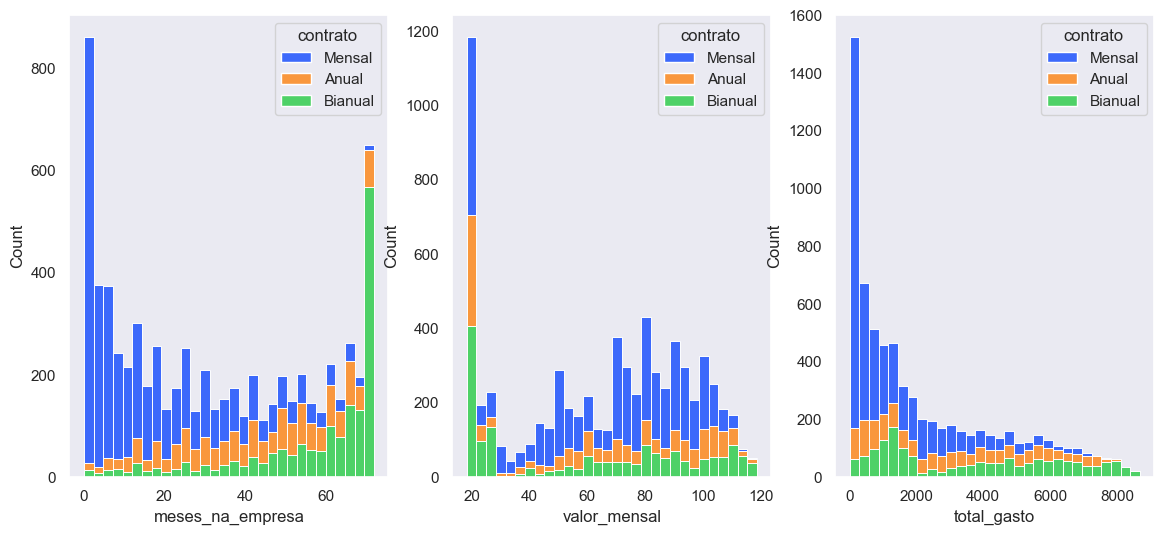

In [56]:
# por padrão do pandas, o número de barras do histograma eram 10. No seaborn isso muda.
# a depender do número de barras, a análise pode ficar um pouco comprometida, afetando a forma como compreendemos os dados

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(14, 6))

for i, coluna in enumerate(colunas_numericas):
    sns.histplot(x=coluna, data=df_churn, hue='contrato', multiple='stack', ax=axs[i], bins=30)

plt.show()

In [57]:
# para resolver esse problema, podemos utilizar outros gráficos, como o KDE (identidade de Kernel)